# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.

## Alumno:    Felipe Berganza

# Resumen 

Este trabajo analiza el fenómeno de la fuga espectral en la Transformada Discreta de Fourier (DFT) mediante la simulación de tres señales senoidales con distintos grados de desintonía respecto a los centros de los bins (bin exacto, desintonía leve y máxima fuga). El estudio incluye la verificación de la Identidad de Parseval para asegurar la conservación de la energía entre los dominios del tiempo y la frecuencia, y emplea la técnica de zero-padding como método de interpolación para visualizar la respuesta continua del espectro. A través de gráficos comparativos en escala logarítmica (dB), se demuestra cómo la energía se dispersa entre bins adyacentes cuando la frecuencia no es un múltiplo entero de la resolución espectral, revelando la forma del lóbulo principal y los lóbulos laterales de la ventana aplicada.

# Introduccion

## FFT (Fast Fourier Transform) 

La FFT (Fast Fourier Transform) no es una transformación distinta a la DFT (Transformada Discreta de Fourier), sino un algoritmo eficiente para calcularla. Toma una señal en el dominio del tiempo (una secuencia de muestras de amplitud) y la descompone en sus componentes de frecuencia. Nos dice qué tan presente está cada frecuencia (amplitud) y en qué momento de su ciclo empieza (fase).

# 1. La base matemática: La DFT


La FFT calcula la sumatoria de la DFT de manera optimizada:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} kn}$$

    Donde:
    
$x[n]$ es la señal de entrada.

$N$ es el número total de muestras.

$k$ representa el "bin" o índice de frecuencia.

$e^{-j...}$ es el factor de rotación (complejo) que proyecta la señal sobre senos y cosenos.

# 2. Conceptos Fundamentales

Frecuencia de Muestreo ($f_s$): Es la cantidad de muestras por segundo. Define el rango de frecuencias que podemos ver.

Frecuencia de Nyquist: Es $f_s / 2$. Es la frecuencia máxima que podemos representar sin ambigüedad (aliasing).

Resolución Espectral ($\Delta f$): Es la distancia entre cada punto (bin) del espectro. Se calcula como:$$\Delta f = \frac{f_s}{N}$$

Complejidad Algorítmica:

Una DFT "normal" tarda $O(N^2)$.

La FFT (usando el algoritmo de Cooley-Tukey) tarda $O(N \log N)$. 

# 3. Fenómenos Críticos en la FFT

## A. Fuga Espectral (Spectral Leakage)

Ocurre cuando la señal no es periódica dentro de la ventana de tiempo analizada (la frecuencia no cae exactamente en un "bin"). La energía del pico principal "se desparrama" hacia los bins adyacentes.

## B. Enventanado (Windowing)

Para reducir la fuga espectral, multiplicamos la señal por una ventana (como Hamming, Hann o Blackman). Estas suavizan los bordes de la señal para que parezca periódica, a costa de ensanchar un poco el lóbulo principal.

## C. Zero Padding

Consiste en agregar ceros al final de la señal original.

No mejora la resolución real (no separa frecuencias muy juntas).

Sí mejora la resolución visual, actuando como una interpolación que nos permite ver mejor la forma de los lóbulos.


# DESARROLLO 

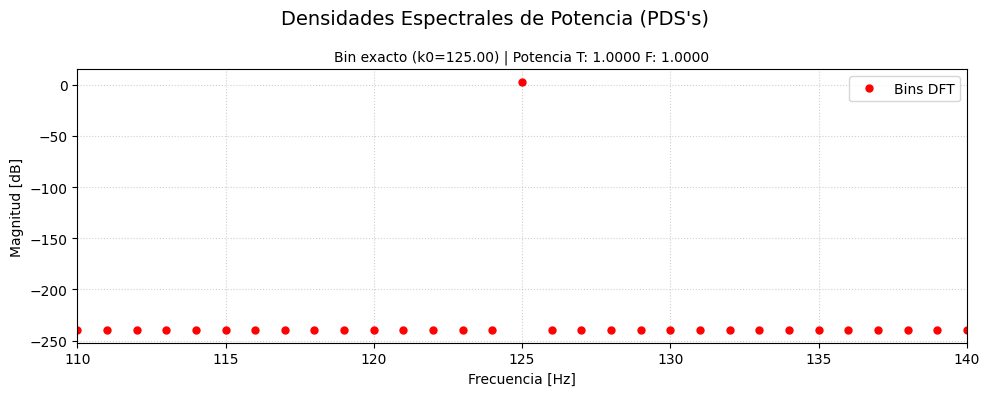

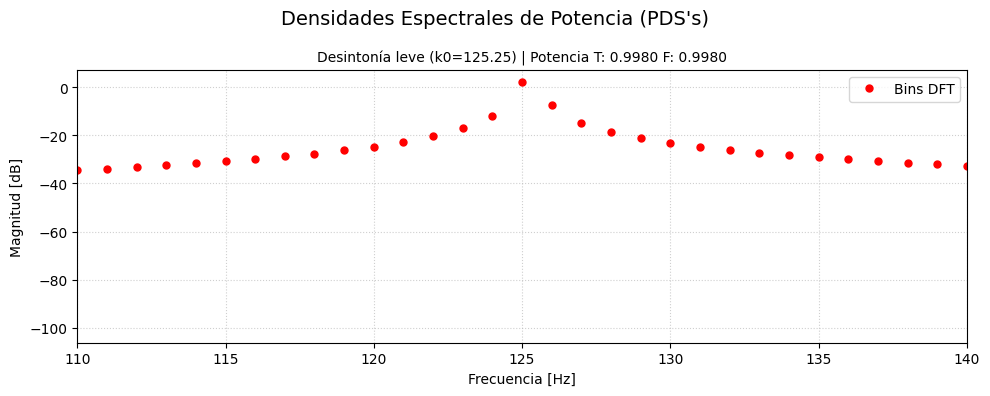

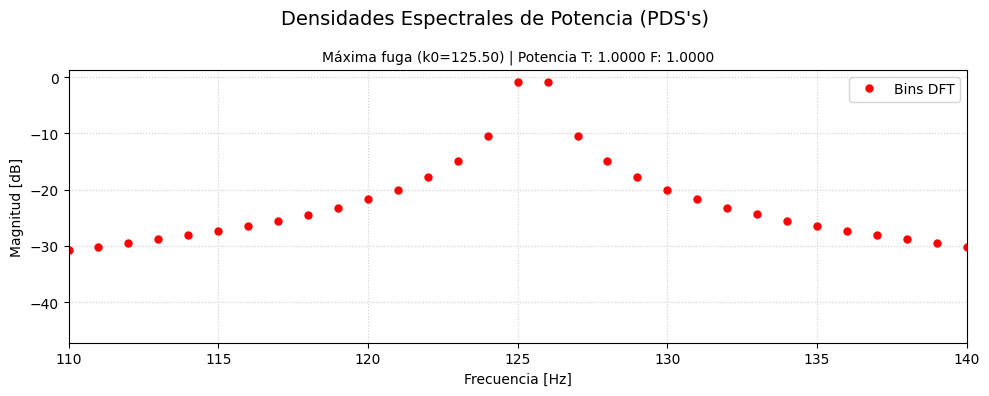

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    """
    Genera una señal senoidal.
    """
    ts = 1/fs
    tt = np.arange(nn) * ts
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    return tt, xx

# %% Parámetros
vmax = np.sqrt(2)
dc = 0 
ph = 0 
nn = 500 
fs = 500 
df = fs / nn

# Frecuencias 
f0 = (nn/4) * df         # 125.0 Hz (Bin exacto)
f1 = (nn/4 + 0.25) * df  # 125.25 Hz
f2 = (nn/4 + 0.5) * df   # 125.5 Hz (Máxima fuga)

#%%
# Generacion de senales 
tt, s0 = mi_funcion_sen(vmax, dc, f0, ph, nn, fs)
tt, s1 = mi_funcion_sen(vmax, dc, f1, ph, nn, fs)
tt, s2 = mi_funcion_sen(vmax, dc, f2, ph, nn, fs)

# ---  Identidad de Parseval (Punto b) ---
# Potencia en el tiempo
pot_tiempo0 = np.mean(s0**2)
pot_tiempo1 = np.mean(s1**2)
pot_tiempo2 = np.mean(s2**2)
    
# FFT sin padding
# Dividimos por N para que la magnitud sea independiente del largo de la señal
XX_s0 = np.fft.fft(s0) / nn
XX_s1 = np.fft.fft(s1) / nn
XX_s2 = np.fft.fft(s2) / nn   
# Potencia en frecuencia (Suma de los cuadrados de los bins)
pot_frec0 = np.sum(np.abs(XX_s0)**2)
pot_frec1 = np.sum(np.abs(XX_s1)**2)
pot_frec2 = np.sum(np.abs(XX_s2)**2)
    
# Espectro unilateral para graficar (multiplicamos por 2 para conservar energía)
psd_s0 = np.abs(XX_s0)**2
psd_s0[1:nn//2] *= 2
frec_s = np.arange(0, fs/2, df)


psd_s1 = np.abs(XX_s1)**2
psd_s1[1:nn//2] *= 2 


psd_s2 = np.abs(XX_s2)**2
psd_s2[1:nn//2] *= 2 

# %% Generación de gráficos 

# Lista de datos para iterar y generar gráficos separados
datos = [
    (s0, XX_s0, f0, pot_tiempo0, pot_frec0, "Bin exacto"),
    (s1, XX_s1, f1, pot_tiempo1, pot_frec1, "Desintonía leve"),
    (s2, XX_s2, f2, pot_tiempo2, pot_frec2, "Máxima fuga")
]

for s, XX, freq, p_t, p_f, nombre in datos:
    plt.figure(figsize=(10, 4))
    
    # 2. Bins originales de la DFT
    # Normalización consistente para los puntos rojos
    psd_puntos = np.abs(XX[:nn//2] / (1/2))
    plt.plot(frec_s, 20 * np.log10(psd_puntos + 1e-12), 'ro', markersize=5, label='Bins DFT')
    
    # Títulos y formato
    plt.suptitle("Densidades Espectrales de Potencia (PDS's)", fontsize=14)
    plt.title(f"{nombre} (k0={freq/df:.2f}) | Potencia T: {p_t:.4f} F: {p_f:.4f}", fontsize=10)
    
    plt.xlim([110, 140])
    plt.ylabel("Magnitud [dB]")
    plt.xlabel("Frecuencia [Hz]")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

El análisis demuestra que la fuga espectral depende estrictamente de la alineación entre la frecuencia de la señal y la resolución del bin ($\Delta f$); mientras que una señal sintonizada concentra toda su potencia en un único bin (como podemos verlo en el grafico de la PSD con un k0 = 125 Hz), luego al tener  una desintonía mínima (de apenas unos Hertz como lo vemos en los ultimos dos graficos) provoca que la energía se disperse hacia los bins adyacentes, alterando drásticamente la visualización del espectro a pesar de que la potencia total se mantiene constante según la identidad de Parseval.  Esta diferencia visual ocurre porque la DFT asume periodicidad en la ventana observada: cuando la frecuencia no es un múltiplo exacto de $\Delta f$, se producen discontinuidades en los extremos de la muestra que generan componentes de frecuencia inexistentes en la señal original, fenómeno que el zero-padding permite suavizar al interpolar la forma real del lóbulo del kernel de la ventana, pero sin alterar la resolución física subyacente.

# Zero Padding 

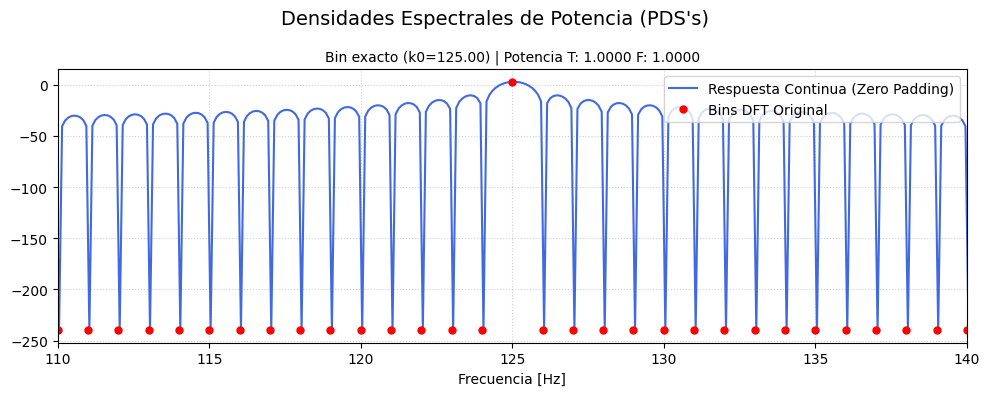

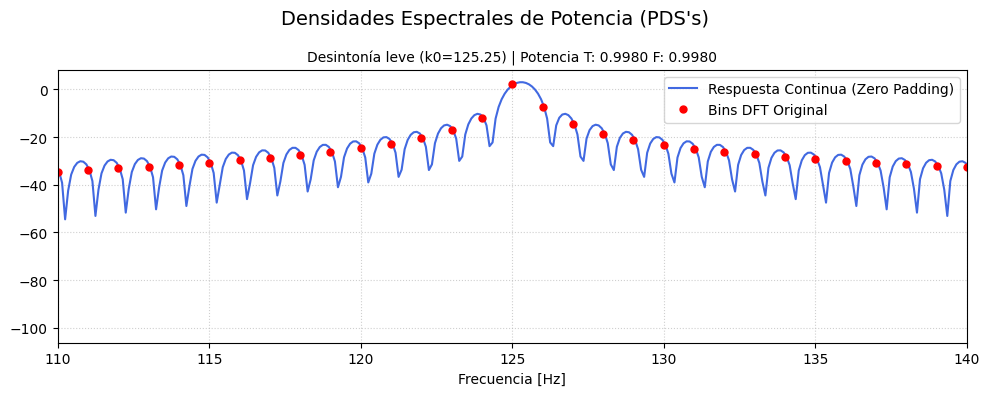

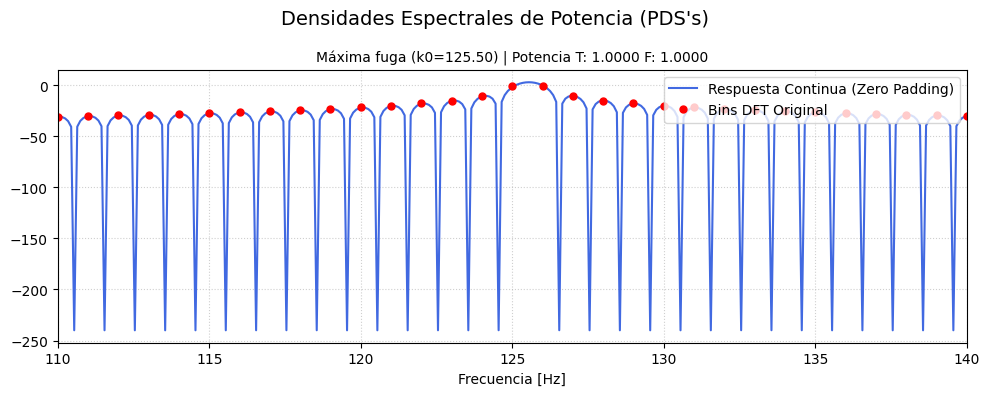

In [3]:
#%%

# técnica de zero padding

cant_padds = 9


sp0 = np.concatenate((s0, np.zeros(nn * cant_padds)))
sp1 = np.concatenate((s1, np.zeros(nn * cant_padds)))
sp2 = np.concatenate((s2, np.zeros(nn * cant_padds)))
N_total = len(sp0)

# ---  Identidad de Parseval (Punto b) ---
# Potencia en el tiempo
pot_tiempo0 = np.sum(s0**2) / nn  
pot_tiempo1 = np.sum(s1**2) / nn
pot_tiempo2 = np.sum(s2**2) / nn
    
# FFT con padding
# Dividimos por N para que la magnitud sea independiente del largo de la señal
XX_sp0 = np.fft.fft(sp0) / nn
XX_sp1 = np.fft.fft(sp1) / nn
XX_sp2 = np.fft.fft(sp2) / nn   
# Potencia en frecuencia (Suma de los cuadrados de los bins)
# Dividimos por (1 + cant_padds) para compensar los bins adicionales
factor_padding = 1 + cant_padds

pot_frec0 = np.sum(np.abs(XX_sp0)**2) / factor_padding
pot_frec1 = np.sum(np.abs(XX_sp1)**2) / factor_padding
pot_frec2 = np.sum(np.abs(XX_sp2)**2) / factor_padding

    
# Espectro unilateral para graficar (multiplicamos por 2 para conservar energía)
psd_sp0 = np.abs(XX_sp0)**2
psd_sp0[1:nn//2] *= 2
frec_s = np.arange(0, fs/2, df)


psd_sp1 = np.abs(XX_sp1)**2
psd_sp1[1:nn//2] *= 2 


psd_sp2 = np.abs(XX_sp2)**2
psd_sp2[1:nn//2] *= 2 

# %% Generación de gráficos con padding 

# Parámetros de frecuencia para el padding
# N_total ya lo definiste como len(sp0)
frec_sf = np.linspace(0, fs/2, N_total//2)

# Lista de datos  (usando las señales con padding y las originales)
datos = [
    (s0, sp0, XX_s0, f0, pot_tiempo0, pot_frec0, "Bin exacto"),
    (s1, sp1, XX_s1, f1, pot_tiempo1, pot_frec1, "Desintonía leve"),
    (s2, sp2, XX_s2, f2, pot_tiempo2, pot_frec2, "Máxima fuga")
]

for s_orig, s_pad, XX_orig, freq, p_t, p_f, nombre in datos:
    plt.figure(figsize=(10, 4))
    
    # 1. Respuesta Continua (Línea Azul con Zero Padding)
    # Calculamos la FFT de la señal con padding ya normalizada
    XX_pad = np.fft.fft(s_pad) / (nn/2) 
    psd_pad = np.abs(XX_pad[:N_total//2])
    plt.plot(frec_sf, 20 * np.log10(psd_pad + 1e-12), color='royalblue', label='Respuesta Continua (Zero Padding)')
    
    # 2. Bins originales de la DFT (Puntos Rojos)
    # Usamos la FFT de la señal original (sin padding)
    psd_puntos = np.abs(XX_orig[:nn//2] / (1/2))
    plt.plot(frec_s, 20 * np.log10(psd_puntos + 1e-12), 'ro', markersize=5, label='Bins DFT Original')
    
    # Títulos y formato
    plt.suptitle("Densidades Espectrales de Potencia (PDS's)", fontsize=14)
    plt.title(f"{nombre} (k0={freq/df:.2f}) | Potencia T: {p_t:.4f} F: {p_f:.4f}", fontsize=10)
    
    plt.xlim([110, 140])
    plt.xlabel("Frecuencia [Hz]")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


En esta sección del código se implementa la técnica de Zero Padding, la cual consiste en añadir muestras con valor cero al final de la señal original antes de calcular la FFT.

¿Qué estamos observando en los gráficos?

Interpolación Espectral: Al agregar ceros (cant_padds = 9), el espectro resultante (línea azul) se ve mucho más suave. Es importante notar que no se ha mejorado la resolución real (la capacidad de distinguir dos frecuencias cercanas), sino que se ha realizado una interpolación. Esto nos permite ver la "forma real" del lóbulo de la ventana rectangular que antes estaba oculta.

Revelación de la Fuga (Leakage):

En el caso del Bin Exacto, se ve que el punto rojo (DFT original) coincide justo con el pico del lóbulo.

En los casos de Desintonía, los puntos rojos "muestrean" el lóbulo en lugares donde la amplitud es menor, lo que explica por qué en la DFT original parece que perdemos energía o que el pico es más bajo. La línea azul demuestra que el pico sigue ahí, solo que la DFT original "no lo vio".'

vale aclarar que aunque agreguemos ceros, la energía total de la señal no cambia, por lo que la potencia calculada en frecuencia debe seguir coincidiendo con la del tiempo (Potencia T $\approx$ Potencia F).

# Conclusion Final 

El análisis realizado permite concluir que la Transformada Rápida de Fourier (FFT) es una herramienta poderosa pero sensible a la relación entre la frecuencia de la señal y la resolución espectral del sistema ($\Delta f$). A través de las simulaciones, se demostró que la fuga espectral no es un error de cálculo, sino una consecuencia matemática de observar una señal a través de una "ventana" de tiempo finita: cuando la señal no completa ciclos exactos dentro de esa ventana, la energía se dispersa entre múltiples bins.La implementación del Zero-Padding resultó fundamental para comprender este fenómeno de forma visual. Se comprobó que, aunque añadir ceros no mejora la resolución física (no permite distinguir dos tonos muy cercanos), actúa como un reconstructor que interpola el espectro, revelando la verdadera forma del lóbulo de la señal y demostrando que el pico de potencia siempre existe, aunque la DFT original no coincida con él. Finalmente, la verificación mediante la Identidad de Parseval confirmó que, independientemente de la desintonía o el procesado aplicado, la energía total se conserva, garantizando la integridad física del análisis en ambos dominios.